In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("data\StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [9]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

exploring the the data


In [11]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
print(" categories in 'gender' variables", end=" ")
print(df['gender'].unique())

print("categoriies in 'race/ethnicity' variables", end=" ")
print(df['race/ethnicity'].unique())

print(" categories in 'parental level of education' variables", end=" ")
print(df['parental level of education'].unique())

print("categoriies in 'lunch' variables ", end=" ")
print(df['lunch'].unique())

print("cactegories in 'test preparation variables", end=" ")
print(df['test preparation course'].unique())

 categories in 'gender' variables <StringArray>
['female', 'male']
Length: 2, dtype: str
categoriies in 'race/ethnicity' variables <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
 categories in 'parental level of education' variables <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categoriies in 'lunch' variables  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
cactegories in 'test preparation variables <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
numeric_features = [feature for feature in df.columns if df[feature].dtype !=  "str"]
categorical_features = [feature for feature in df.columns if df[feature].dtype ==  "str"]

print('we have {} numeric_features :{}'.format(len(numeric_features), numeric_features))
print('\nwe have {} categorical_features :{}'.format(len(categorical_features), categorical_features))
                                                

we have 3 numeric_features :['math score', 'reading score', 'writing score']

we have 5 categorical_features :['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [14]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [15]:
df['total score'] = df['math score']+df['reading score']+df['writing score']
df['average score'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
math_full = df[df['math score']==100]['average score'].count()
reading_full = df[df['reading score']==100]['average score'].count()
writing_full = df[df['writing score']==100]['average score'].count()

print(f"total number of students that gets full marks in maths : {math_full}")
print(f"total number of students that gets full marks in reading : {reading_full}")
print(f"total number of students that gets full marks in writing : {writing_full}")

total number of students that gets full marks in maths : 7
total number of students that gets full marks in reading : 17
total number of students that gets full marks in writing : 14


In [17]:
math_less_than_30 = df[df['math score']<=30]['average score'].count()
reading_less_than_30 = df[df['reading score']<=30]['average score'].count()
writing_less_than_30 = df[df['writing score']<=30]['average score'].count()

print(f"number of students that got less than 30 in maths : {math_less_than_30}")
print(f"number of students that got less than 30 in reading : {reading_less_than_30}")
print(f"number of students that got less than 30 in writing : {writing_less_than_30}")

number of students that got less than 30 in maths : 16
number of students that got less than 30 in reading : 8
number of students that got less than 30 in writing : 10


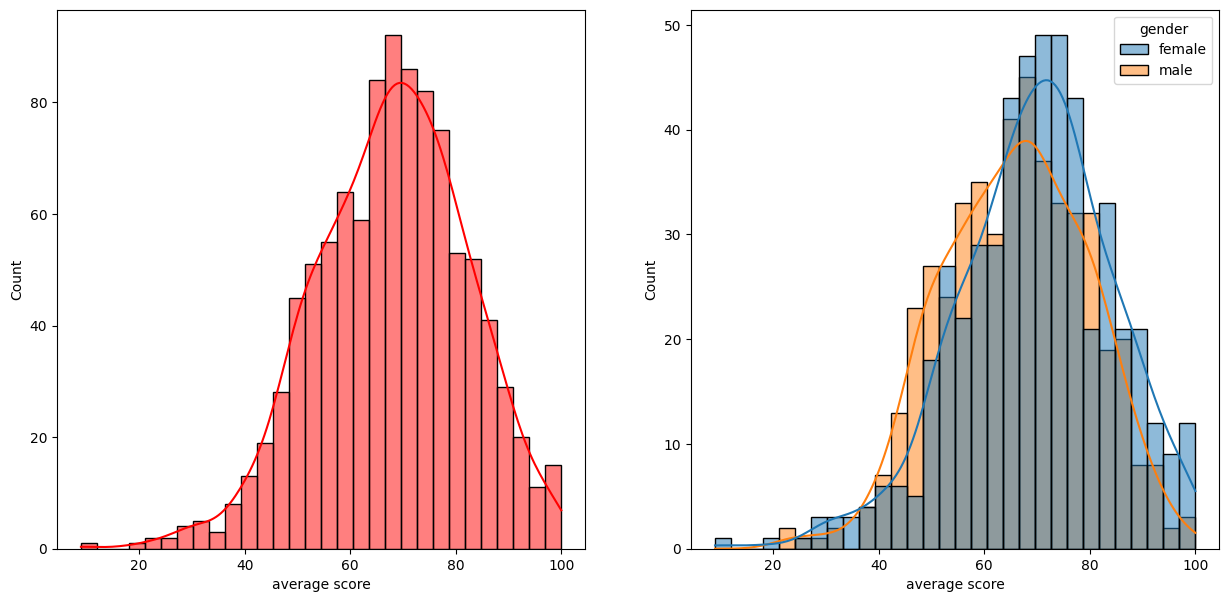

In [18]:
fig , axs = plt.subplots(1, 2 , figsize=(15, 7))
plt.subplot(121)

sns.histplot(data=df, x='average score', bins = 30 , kde =True, color ="red")
plt.subplot(122)
sns.histplot(data=df, x='average score', bins =30 ,kde = True, hue = 'gender')
plt.show()

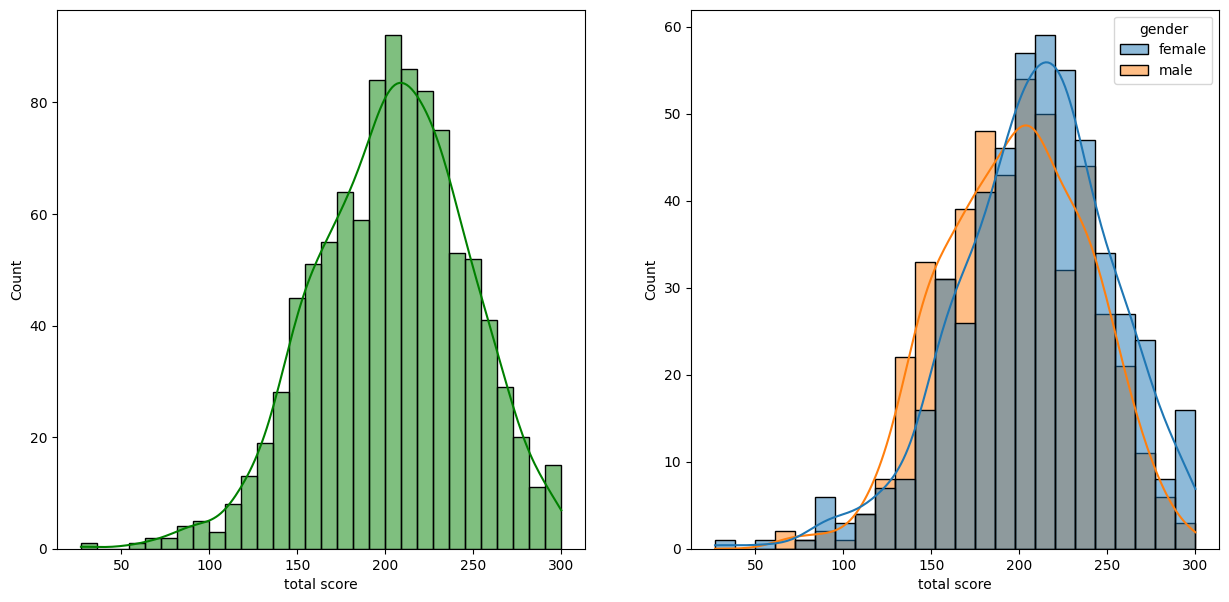

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()


Insight



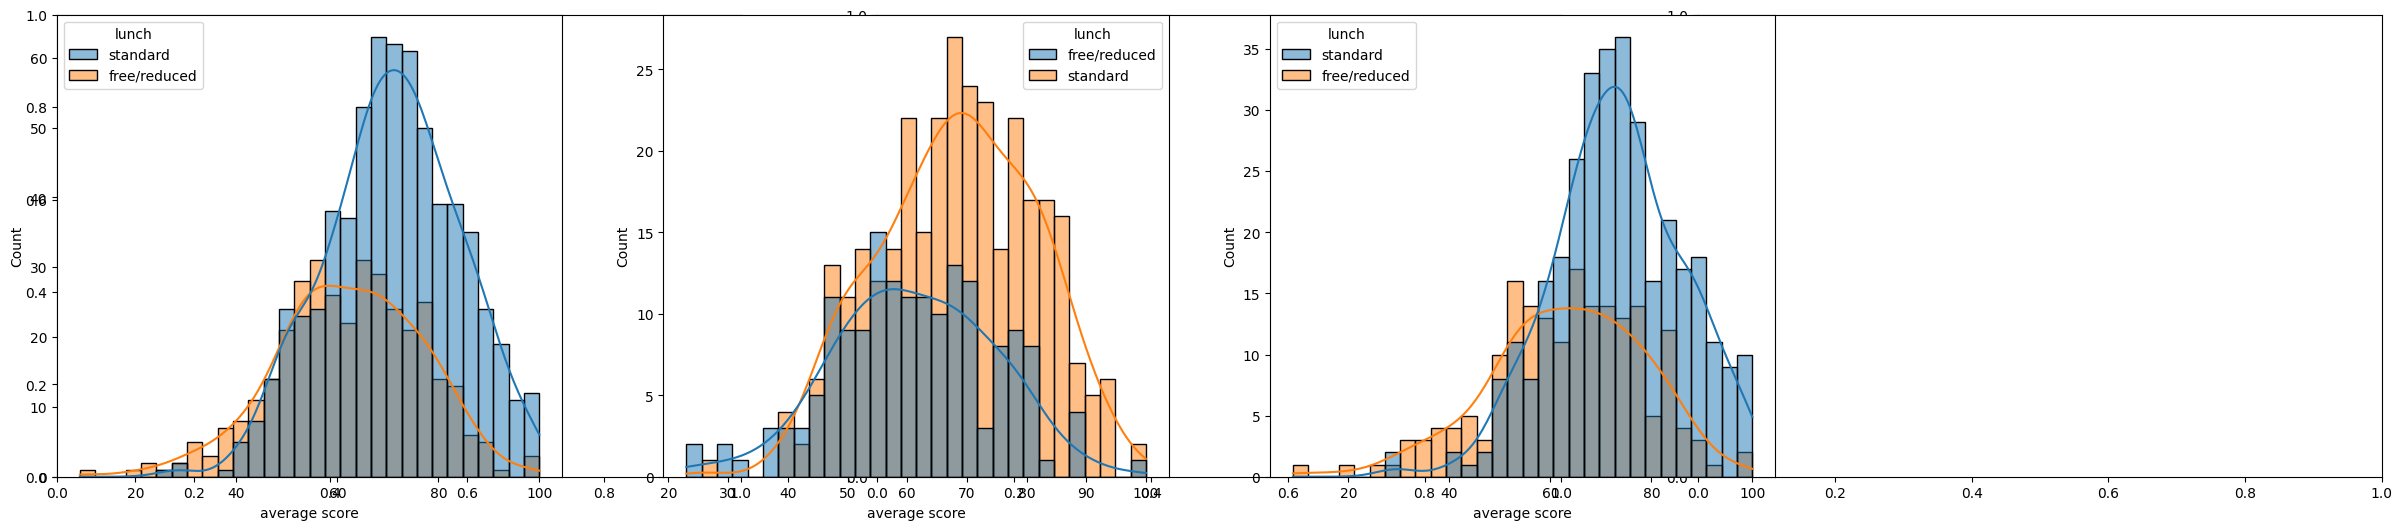

In [42]:
fig1, axs1 = plt.subplots(1, 3, figsize=(30, 6))
plt.subplot(141)
sns.histplot(data=df, x ="average score", bins=30, kde =True, hue = 'lunch' )
plt.subplot(142)
sns.histplot(data=df[df.gender == 'male'], x="average score", bins=30, kde=True , hue ='lunch' )
plt.subplot(143)
sns.histplot(data=df[df.gender == 'female'], x='average score', bins=30, kde=True, hue = 'lunch' )
plt.show()



In [ ]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
sns.histplot(data=df,x='average score',kde=True,hue='parental level of education')
plt.subplot(132)
sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='parental level of education')
plt.subplot(133)
sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='parental level of education')
plt.show()

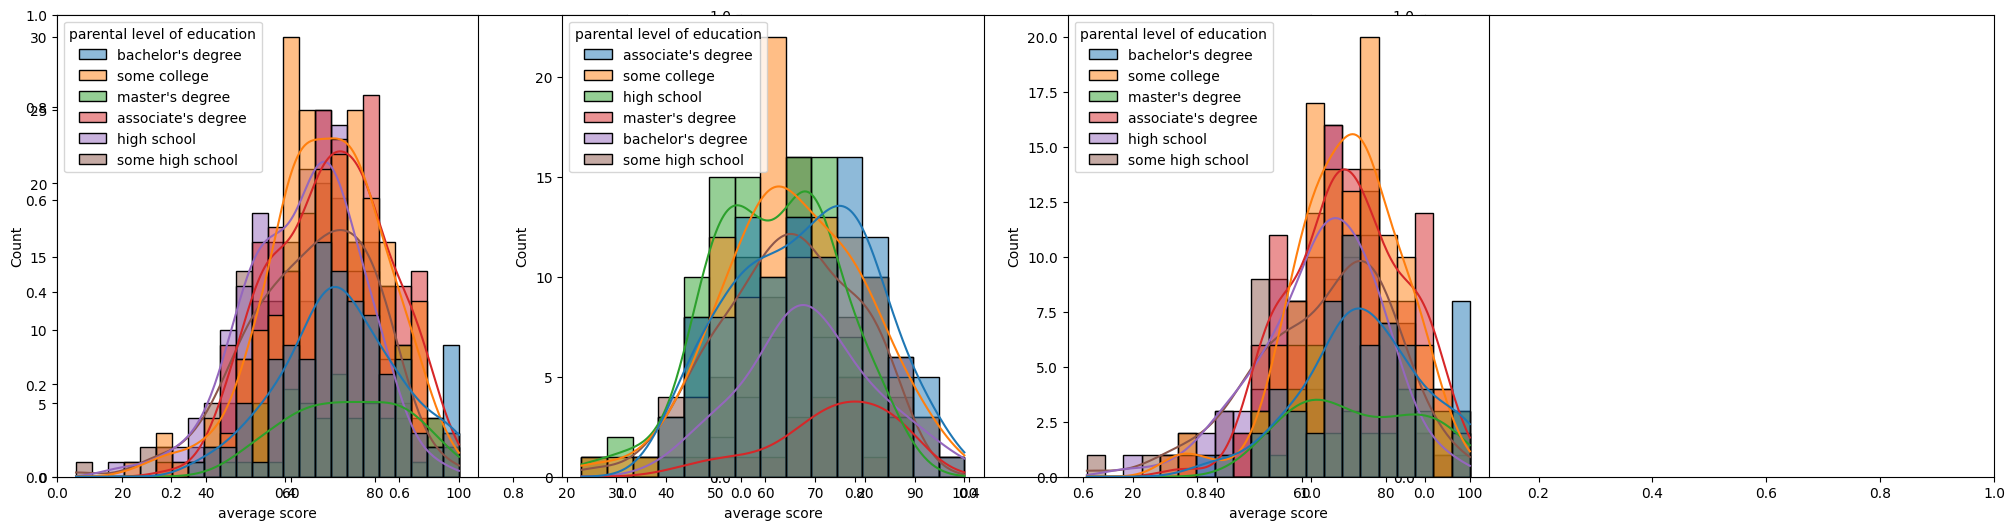

In [43]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average score',kde=True,hue='parental level of education')
plt.subplot(142)
sns.histplot(data=df[df.gender=='male'],x='average score',kde=True,hue='parental level of education')
plt.subplot(143)
sns.histplot(data=df[df.gender=='female'],x='average score',kde=True,hue='parental level of education')
plt.show()